## 1. Carga e instalación de librerías

In [2]:
!pip install pandas plotly
!pip install pandas folium geopandas branca

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap, MarkerCluster

## 2. Cargar el dataset en Jupyter Notebook

Se carga el dataset generado en la Práctica 08, que ya incluye `municipio_objetivo` (el municipio real de cada paciente, obtenido por unión espacial). Es mejor partir de ese archivo en lugar del CSV original, porque ya tiene la columna correcta para filtrar por municipio

In [4]:
import pandas as pd

df = pd.read_csv("../practica_08/data/raw/dataset_diabetes_puebla_final.csv")

df.head()

,id_paciente,estado,municipio,zona,edad,genero,nivel_socioeconomico,antecedentes_familiares_diabetes,embarazos,imc,...,horas_sueno,indice_calidad_dieta,azucar_diario_g,frecuencia_ultraprocesados_semana,latitud,longitud,geometry,index_right,NOMGEO,municipio_objetivo
0,1,Puebla,Puebla,Urbana,64,M,Medio,0,0,25.6,...,5.6,33,86,10,19.040804,-98.230139,POINT (-98.230139 19.040804),94.0,Puebla,Puebla
1,3,Puebla,Puebla,Urbana,51,F,Alto,0,3,36.3,...,7.3,88,27,11,19.040216,-98.201709,POINT (-98.201709 19.040216),94.0,Puebla,Puebla
2,4,Puebla,Amozoc,Rural,49,M,Bajo,1,0,24.4,...,8.1,84,57,4,19.052129,-98.047388,POINT (-98.047388 19.052129),53.0,Amozoc,Amozoc
3,5,Puebla,San Martin Texmelucan,Rural,29,M,Medio,0,0,27.8,...,7.5,59,85,10,19.258587,-98.434323,POINT (-98.434323 19.258587),206.0,San Martín Texmelucan,San Martín Texmelucan
4,6,Puebla,San Andres Cholula,Urbana,40,F,Medio,1,1,27.2,...,8.6,69,95,9,19.072860,-98.306480,POINT (-98.30648 19.07286),68.0,San Pedro Cholula,San Pedro Cholula


## 3. Verificar la estructura del dataset

Se revisan columnas, tipos de datos, cantidad de registros y valores nulos, para tener un panorama general antes de filtrar y modelar.

In [5]:
print("Filas y columnas:", df.shape)
print()
print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores nulos por columna:")
print(df.isnull().sum())
print()
print("Estadísticas descriptivas (variables numéricas):")
df.describe()

Filas y columnas: (21238, 32)

Tipos de datos:
id_paciente                            int64
estado                                   str
municipio                                str
zona                                     str
edad                                   int64
genero                                   str
nivel_socioeconomico                     str
antecedentes_familiares_diabetes       int64
embarazos                              int64
imc                                  float64
circunferencia_cintura_cm            float64
presion_sistolica                      int64
presion_diastolica                     int64
trigliceridos_mgdl                     int64
hdl_mgdl                               int64
glucosa_ayunas_mgdl                    int64
hba1c_pct                            float64
ogtt_2h_mgdl                           int64
insulina_serica_uUmL                 float64
actividad_fisica_min_semana            int64
fumador                                int64
consumo_

,id_paciente,edad,antecedentes_familiares_diabetes,embarazos,imc,circunferencia_cintura_cm,presion_sistolica,presion_diastolica,trigliceridos_mgdl,hdl_mgdl,...,insulina_serica_uUmL,actividad_fisica_min_semana,fumador,horas_sueno,indice_calidad_dieta,azucar_diario_g,frecuencia_ultraprocesados_semana,latitud,longitud,index_right
count,21238.000000,21238.000000,21238.000000,21238.000000,21238.000000,21238.000000,21238.000000,21238.000000,21238.000000,21238.000000,...,21238.000000,21238.000000,21238.000000,21238.000000,21238.000000,21238.000000,21238.000000,21238.000000,21238.000000,21238.000000
mean,10998.489265,44.214992,0.367784,1.111074,27.360439,70.217808,123.276862,78.729212,149.815190,46.322300,...,9.518090,117.875883,0.199736,6.903578,53.213768,68.704492,8.762690,19.190721,-98.010786,103.390762
std,6347.190206,14.499041,0.482214,1.477667,5.883505,13.375667,15.231432,9.955875,56.584575,12.032922,...,6.718937,111.246425,0.399812,1.292907,18.420163,31.298508,3.434944,0.485820,0.376586,50.121902
min,1.000000,18.000000,0.000000,0.000000,15.000000,55.000000,85.000000,55.000000,40.000000,15.000000,...,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,18.436637,-98.493943,2.000000
25%,5510.250000,34.000000,0.000000,0.000000,23.200000,57.400000,113.000000,72.000000,110.000000,38.000000,...,3.700000,39.000000,0.000000,6.000000,41.000000,47.000000,6.000000,18.956105,-98.300438,68.000000
50%,11001.500000,44.000000,0.000000,0.000000,27.300000,68.400000,123.000000,79.000000,149.000000,46.000000,...,8.900000,84.000000,0.000000,6.900000,53.000000,68.000000,9.000000,19.049747,-98.185000,94.000000
75%,16483.750000,54.000000,1.000000,2.000000,31.400000,79.275000,133.000000,85.000000,188.000000,54.000000,...,14.100000,162.000000,0.000000,7.800000,66.000000,90.000000,11.000000,19.627263,-97.696832,148.000000
max,22000.000000,90.000000,1.000000,9.000000,50.500000,129.600000,178.000000,130.000000,389.000000,94.000000,...,40.800000,900.000000,1.000000,11.000000,100.000000,197.000000,24.000000,20.297476,-97.205045,206.000000


## 4. Filtrar pacientes de Xicotepec de Juárez

Se filtran únicamente los pacientes cuyo `municipio_objetivo` corresponde a Xicotepec. El nombre oficial del INEGI en el shapefile suele ser **"Xicotepec de Juárez"** (como viste con otros municipios de tu dataset, por ejemplo "Cuetzalan del Progreso" en vez de solo "Cuetzalan"), así que conviene filtrar con `str.contains` en lugar de una comparación exacta, para no perder registros por una diferencia de nombre.

In [6]:
# Revisamos primero cómo aparece exactamente el nombre en tu dataset
municipios_unicos = pd.Series(df['municipio_objetivo'].unique())
print(municipios_unicos[municipios_unicos.str.contains('Xicotepec', case=False, na=False)])

df_xicotepec = df[df['municipio_objetivo'].str.contains('Xicotepec', case=False, na=False)].copy()

print("Pacientes de Xicotepec:", df_xicotepec.shape[0])
df_xicotepec.head()

20    Xicotepec
dtype: str
Pacientes de Xicotepec: 572


,id_paciente,estado,municipio,zona,edad,genero,nivel_socioeconomico,antecedentes_familiares_diabetes,embarazos,imc,...,horas_sueno,indice_calidad_dieta,azucar_diario_g,frecuencia_ultraprocesados_semana,latitud,longitud,geometry,index_right,NOMGEO,municipio_objetivo
97,102,Puebla,Xicotepec,Rural,44,F,Bajo,1,1,28.3,...,8.1,49,111,6,20.287225,-97.942684,POINT (-97.942684 20.287225),56.0,Xicotepec,Xicotepec
111,116,Puebla,Xicotepec,Rural,67,M,Bajo,0,0,17.3,...,6.2,62,20,10,20.291453,-97.962279,POINT (-97.962279 20.291453),56.0,Xicotepec,Xicotepec
149,156,Puebla,Xicotepec,Rural,32,F,Bajo,0,2,28.5,...,6.6,92,41,2,20.283065,-97.946518,POINT (-97.946518 20.283065),56.0,Xicotepec,Xicotepec
170,177,Puebla,Xicotepec,Rural,55,F,Bajo,1,0,36.1,...,6.7,40,52,6,20.285593,-97.959995,POINT (-97.959995 20.285593),56.0,Xicotepec,Xicotepec
180,187,Puebla,Xicotepec,Rural,21,M,Bajo,1,0,23.3,...,9.1,57,36,7,20.293099,-97.961084,POINT (-97.961084 20.293099),56.0,Xicotepec,Xicotepec


## 5. Validar el volumen de registros filtrados

Antes de avanzar, hay que confirmar que Xicotepec tenga pacientes suficientes para entrenar un modelo multiclase (con 4 niveles de riesgo, si algún nivel queda con muy pocos casos, el modelo no podrá aprenderlo bien).

In [7]:
n_pacientes = df_xicotepec.shape[0]
print(f"Pacientes de Xicotepec: {n_pacientes}")

if n_pacientes < 200:
    print("⚠️ Volumen bajo: con menos de 200 registros, el análisis multiclase puede no ser confiable.")
elif n_pacientes < 500:
    print("⚠️ Volumen moderado: alcanza para el análisis, pero conviene documentar esta limitación.")
else:
    print("✅ Volumen suficiente para continuar con el análisis supervisado.")

Pacientes de Xicotepec: 572
✅ Volumen suficiente para continuar con el análisis supervisado.


### 6. Revisar variables clínicas disponibles

Se identifican las columnas relacionadas con salud cardiovascular presentes en tu dataset.

In [8]:
variables_clinicas_candidatas = [
    'edad', 'presion_sistolica', 'presion_diastolica', 'glucosa_ayunas_mgdl',
    'hba1c_pct', 'ogtt_2h_mgdl', 'insulina_serica_uUmL', 'trigliceridos_mgdl',
    'hdl_mgdl', 'imc', 'circunferencia_cintura_cm', 'fumador',
    'actividad_fisica_min_semana', 'antecedentes_familiares_diabetes',
    'consumo_alcohol', 'diabetes'
]

variables_clinicas = [c for c in variables_clinicas_candidatas if c in df_xicotepec.columns]

print("Variables clínicas disponibles:")
print(variables_clinicas)
df_xicotepec[variables_clinicas].describe()

Variables clínicas disponibles:
['edad', 'presion_sistolica', 'presion_diastolica', 'glucosa_ayunas_mgdl', 'hba1c_pct', 'ogtt_2h_mgdl', 'insulina_serica_uUmL', 'trigliceridos_mgdl', 'hdl_mgdl', 'imc', 'circunferencia_cintura_cm', 'fumador', 'actividad_fisica_min_semana', 'antecedentes_familiares_diabetes', 'consumo_alcohol']


,edad,presion_sistolica,presion_diastolica,glucosa_ayunas_mgdl,hba1c_pct,ogtt_2h_mgdl,insulina_serica_uUmL,trigliceridos_mgdl,hdl_mgdl,imc,circunferencia_cintura_cm,fumador,actividad_fisica_min_semana,antecedentes_familiares_diabetes
count,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000
mean,43.776224,122.975524,79.356643,95.346154,5.214336,127.033217,9.005245,151.786713,46.319930,27.329371,69.596329,0.199301,125.234266,0.358392
std,15.434816,15.225891,9.622038,17.873924,0.686679,41.825389,6.454315,58.712216,12.130237,5.841947,13.257209,0.399824,115.264537,0.479948
min,18.000000,85.000000,55.000000,60.000000,4.000000,70.000000,1.000000,40.000000,15.000000,15.000000,55.000000,0.000000,1.000000,0.000000
25%,32.750000,113.000000,73.000000,82.000000,4.700000,92.000000,3.075000,108.000000,38.000000,23.100000,56.575000,0.000000,43.000000,0.000000
50%,43.000000,123.000000,79.000000,95.000000,5.200000,124.000000,8.550000,149.000000,46.000000,27.400000,67.200000,0.000000,90.000000,0.000000
75%,54.000000,134.000000,86.000000,108.000000,5.700000,156.000000,13.425000,195.000000,56.000000,31.400000,78.125000,0.000000,169.500000,1.000000
max,89.000000,165.000000,110.000000,146.000000,7.300000,239.000000,27.500000,329.000000,78.000000,44.800000,118.600000,1.000000,900.000000,1.000000



## 7. Revisar variables demográficas disponibles

Se identifican las columnas demográficas y de características generales del paciente.

In [9]:
variables_demograficas_candidatas = [
    'genero', 'edad', 'zona', 'nivel_socioeconomico', 'horas_sueno',
    'indice_calidad_dieta', 'azucar_diario_g', 'frecuencia_ultraprocesados_semana'
]

variables_demograficas = [c for c in variables_demograficas_candidatas if c in df_xicotepec.columns]

print("Variables demográficas disponibles:")
print(variables_demograficas)
df_xicotepec[variables_demograficas].describe(include='all')

Variables demográficas disponibles:
['genero', 'edad', 'zona', 'nivel_socioeconomico', 'horas_sueno', 'indice_calidad_dieta', 'azucar_diario_g', 'frecuencia_ultraprocesados_semana']


,genero,edad,zona,nivel_socioeconomico,horas_sueno,indice_calidad_dieta,azucar_diario_g,frecuencia_ultraprocesados_semana
count,572,572.000000,572,572,572.000000,572.000000,572.000000,572.000000
unique,2,NaN,2,3,NaN,NaN,NaN,NaN
top,M,NaN,Rural,Bajo,NaN,NaN,NaN,NaN
freq,289,NaN,380,277,NaN,NaN,NaN,NaN
mean,NaN,43.776224,NaN,NaN,6.856993,56.505245,63.781469,7.980769
std,NaN,15.434816,NaN,NaN,1.302310,18.738825,30.167474,3.478930
min,NaN,18.000000,NaN,NaN,3.300000,4.000000,0.000000,0.000000
25%,NaN,32.750000,NaN,NaN,6.000000,44.000000,44.000000,6.000000
50%,NaN,43.000000,NaN,NaN,6.700000,55.000000,63.000000,8.000000
75%,NaN,54.000000,NaN,NaN,7.700000,70.000000,85.000000,10.000000


## 8. Revisar variables geográficas disponibles

Se confirma que existan latitud y longitud, y que estén completas (sin nulos) para poder ubicar a los pacientes en el mapa más adelante.

In [10]:
print("¿Tiene latitud y longitud?:", {'latitud', 'longitud'}.issubset(df_xicotepec.columns))
print("Nulos en latitud:", df_xicotepec['latitud'].isnull().sum())
print("Nulos en longitud:", df_xicotepec['longitud'].isnull().sum())

df_xicotepec[['latitud', 'longitud']].describe()

¿Tiene latitud y longitud?: True
Nulos en latitud: 0
Nulos en longitud: 0


,latitud,longitud
count,572.000000,572.000000
mean,20.283032,-97.949740
std,0.007607,0.007531
min,20.269202,-97.965309
25%,20.276696,-97.955420
50%,20.282967,-97.948869
75%,20.289070,-97.943917
max,20.297476,-97.935293


## 9. Definir la variable objetivo del modelo

Como el dataset no trae un "riesgo de infarto" ya calculado, se construye con una regla clínica simplificada tipo puntaje: cada factor de riesgo cardiovascular presente suma puntos según qué tan alterado esté, y el puntaje total se traduce a 4 niveles (bajo, medio, alto, crítico). Esto es una **aproximación educativa**, no una fórmula médica real — hay que documentarlo así en el README.

In [11]:
def calcular_puntaje_riesgo(row):
    puntos = 0

    # Presión arterial
    if row['presion_sistolica'] >= 180 or row['presion_diastolica'] >= 120:
        puntos += 4  # crisis hipertensiva
    elif row['presion_sistolica'] >= 140 or row['presion_diastolica'] >= 90:
        puntos += 2  # hipertensión
    elif row['presion_sistolica'] >= 130:
        puntos += 1  # presión elevada

    # Glucosa en ayunas
    if row['glucosa_ayunas_mgdl'] >= 250:
        puntos += 3
    elif row['glucosa_ayunas_mgdl'] >= 126:
        puntos += 2
    elif row['glucosa_ayunas_mgdl'] >= 100:
        puntos += 1

    # HbA1c (control glucémico)
    if row['hba1c_pct'] >= 9:
        puntos += 3
    elif row['hba1c_pct'] >= 6.5:
        puntos += 2
    elif row['hba1c_pct'] >= 5.7:
        puntos += 1

    # Perfil lipídico
    if row['trigliceridos_mgdl'] >= 200:
        puntos += 1
    if row['hdl_mgdl'] < 40:
        puntos += 1

    # IMC
    if row['imc'] >= 40:
        puntos += 2
    elif row['imc'] >= 30:
        puntos += 1

    # Edad
    if row['edad'] >= 60:
        puntos += 2
    elif row['edad'] >= 45:
        puntos += 1

    # Tabaquismo
    if str(row.get('fumador', '')).strip().lower() in ('si', 'sí', 'yes', 'fumador', 'true', '1'):
        puntos += 2

    # Antecedentes familiares
    if row.get('antecedentes_familiares_diabetes', 0) == 1:
        puntos += 1

    # Actividad física baja
    if row.get('actividad_fisica_min_semana', 999) < 60:
        puntos += 1

    return puntos

df_xicotepec['puntaje_riesgo'] = df_xicotepec.apply(calcular_puntaje_riesgo, axis=1)

def clasificar_riesgo(puntaje):
    if puntaje <= 3:
        return 'bajo'
    elif puntaje <= 7:
        return 'medio'
    elif puntaje <= 11:
        return 'alto'
    else:
        return 'critico'

df_xicotepec['riesgo_infarto'] = df_xicotepec['puntaje_riesgo'].apply(clasificar_riesgo)

df_xicotepec[['puntaje_riesgo', 'riesgo_infarto']].head(10)

,puntaje_riesgo,riesgo_infarto
97,4,medio
111,2,bajo
149,1,bajo
170,7,medio
180,4,medio
260,1,bajo
285,1,bajo
286,3,bajo
287,6,medio
316,10,alto


## 10. Verificar la distribución de la variable objetivo

Se cuenta cuántos pacientes cayeron en cada nivel de riesgo, para detectar si las clases están balanceadas.

Distribución de niveles de riesgo:
  bajo: 263 pacientes (46.0%)
  medio: 251 pacientes (43.9%)
  alto: 57 pacientes (10.0%)
  critico: 1 pacientes (0.2%)


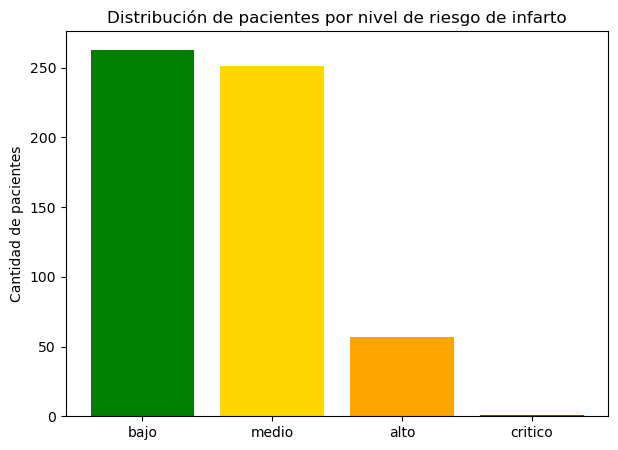

In [12]:
distribucion_riesgo = df_xicotepec['riesgo_infarto'].value_counts()
porcentajes = df_xicotepec['riesgo_infarto'].value_counts(normalize=True) * 100

print("Distribución de niveles de riesgo:")
for nivel in distribucion_riesgo.index:
    print(f"  {nivel}: {distribucion_riesgo[nivel]} pacientes ({porcentajes[nivel]:.1f}%)")

import matplotlib.pyplot as plt

orden = ['bajo', 'medio', 'alto', 'critico']
distribucion_ordenada = distribucion_riesgo.reindex(orden)

plt.figure(figsize=(7, 5))
plt.bar(distribucion_ordenada.index, distribucion_ordenada.values, color=['green', 'gold', 'orange', 'red'])
plt.title("Distribución de pacientes por nivel de riesgo de infarto")
plt.ylabel("Cantidad de pacientes")
plt.show()

## 11. Evitar fuga de información en el modelo

Aquí hay que ser específicos con qué cuenta como fuga real. En tu caso:

- **`puntaje_riesgo`** SÍ es fuga de información grave: es la suma que determina directamente `riesgo_infarto` mediante los umbrales que definimos. Si lo dejas como variable predictora, el modelo "adivinaría" la respuesta casi perfectamente sin aprender nada real — hay que excluirlo de X.
- **Las variables clínicas individuales** (`glucosa_ayunas_mgdl`, `hba1c_pct`, `presion_sistolica`, etc.) que se usaron *para construir* el puntaje **no cuentan como fuga** — al contrario, son justo las variables que el modelo debe usar para aprender a aproximar el riesgo. La fuga se refiere a usar la respuesta ya calculada (o algo equivalente a ella), no a usar los factores clínicos legítimos que la explican.
- También hay que excluir columnas de ubicación/identificación que no aportan valor clínico real y que ya sabemos que no deben ser predictoras: `id_paciente`, `estado`, `municipio`, `municipio_objetivo`, `latitud`, `longitud` (estas últimas dos las vas a usar más adelante para el mapa, no para predecir el riesgo).

In [13]:
columnas_fuga = ['puntaje_riesgo', 'riesgo_infarto']  # la respuesta y su cálculo directo
columnas_no_predictoras = ['id_paciente', 'estado', 'municipio', 'municipio_objetivo',
                            'latitud', 'longitud', 'geometry', 'index_right', 'NOMGEO']

columnas_a_excluir = [c for c in (columnas_fuga + columnas_no_predictoras) if c in df_xicotepec.columns]
print("Columnas excluidas de X:", columnas_a_excluir)

Columnas excluidas de X: ['puntaje_riesgo', 'riesgo_infarto', 'id_paciente', 'estado', 'municipio', 'municipio_objetivo', 'latitud', 'longitud', 'geometry', 'index_right', 'NOMGEO']


## 12. Seleccionar las variables predictoras

Se eligen las columnas clínicas, demográficas y de hábitos que sí pueden usarse legítimamente para predecir el riesgo.

In [14]:
variables_predictoras = [
    'edad', 'genero', 'zona', 'nivel_socioeconomico',
    'presion_sistolica', 'presion_diastolica',
    'glucosa_ayunas_mgdl', 'hba1c_pct', 'ogtt_2h_mgdl', 'insulina_serica_uUmL',
    'trigliceridos_mgdl', 'hdl_mgdl', 'imc', 'circunferencia_cintura_cm',
    'fumador', 'consumo_alcohol', 'actividad_fisica_min_semana',
    'antecedentes_familiares_diabetes', 'embarazos',
    'horas_sueno', 'indice_calidad_dieta', 'azucar_diario_g',
    'frecuencia_ultraprocesados_semana'
]

variables_predictoras = [c for c in variables_predictoras if c in df_xicotepec.columns]
print("Variables predictoras seleccionadas:", variables_predictoras)

Variables predictoras seleccionadas: ['edad', 'genero', 'zona', 'nivel_socioeconomico', 'presion_sistolica', 'presion_diastolica', 'glucosa_ayunas_mgdl', 'hba1c_pct', 'ogtt_2h_mgdl', 'insulina_serica_uUmL', 'trigliceridos_mgdl', 'hdl_mgdl', 'imc', 'circunferencia_cintura_cm', 'fumador', 'consumo_alcohol', 'actividad_fisica_min_semana', 'antecedentes_familiares_diabetes', 'embarazos', 'horas_sueno', 'indice_calidad_dieta', 'azucar_diario_g', 'frecuencia_ultraprocesados_semana']


## 13. Separar variables predictoras y variable objetivo

In [15]:
X = df_xicotepec[variables_predictoras].copy()
y = df_xicotepec['riesgo_infarto'].copy()

print("X:", X.shape, " y:", y.shape)
X.head()

X: (572, 23)  y: (572,)


,edad,genero,zona,nivel_socioeconomico,presion_sistolica,presion_diastolica,glucosa_ayunas_mgdl,hba1c_pct,ogtt_2h_mgdl,insulina_serica_uUmL,...,circunferencia_cintura_cm,fumador,consumo_alcohol,actividad_fisica_min_semana,antecedentes_familiares_diabetes,embarazos,horas_sueno,indice_calidad_dieta,azucar_diario_g,frecuencia_ultraprocesados_semana
97,44,F,Rural,Bajo,140,63,120,5.4,174,11.7,...,70.2,0,Frecuente,175,1,1,8.1,49,111,6
111,67,M,Rural,Bajo,111,89,68,4.0,70,1.0,...,55.0,0,Ocasional,311,0,0,6.2,62,20,10
149,32,F,Rural,Bajo,135,87,98,4.9,133,1.0,...,69.2,0,Nunca,123,0,2,6.6,92,41,2
170,55,F,Rural,Bajo,109,73,132,5.9,209,17.3,...,104.0,0,Frecuente,31,1,0,6.7,40,52,6
180,21,M,Rural,Bajo,103,87,82,5.1,104,6.5,...,55.0,1,Nunca,31,1,0,9.1,57,36,7


## 14. Codificar variables categóricas

Se identifican las columnas de texto/categóricas y se transforman a numéricas con one-hot encoding (`pd.get_dummies`), que es más apropiado que `LabelEncoder` aquí porque estas variables no tienen un orden natural (por ejemplo, "fumador" no es "mayor o menor" que "no fumador").

In [16]:
columnas_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Columnas categóricas detectadas:", columnas_categoricas)

X = pd.get_dummies(X, columns=columnas_categoricas, drop_first=True)

print("X después de codificar:", X.shape)
X.head()

Columnas categóricas detectadas: ['genero', 'zona', 'nivel_socioeconomico', 'consumo_alcohol']
X después de codificar: (572, 25)


C:\Users\DELL\AppData\Local\Temp\ipykernel_17568\618016442.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()


,edad,presion_sistolica,presion_diastolica,glucosa_ayunas_mgdl,hba1c_pct,ogtt_2h_mgdl,insulina_serica_uUmL,trigliceridos_mgdl,hdl_mgdl,imc,...,horas_sueno,indice_calidad_dieta,azucar_diario_g,frecuencia_ultraprocesados_semana,genero_M,zona_Urbana,nivel_socioeconomico_Bajo,nivel_socioeconomico_Medio,consumo_alcohol_Nunca,consumo_alcohol_Ocasional
97,44,140,63,120,5.4,174,11.7,143,52,28.3,...,8.1,49,111,6,False,False,True,False,False,False
111,67,111,89,68,4.0,70,1.0,99,41,17.3,...,6.2,62,20,10,True,False,True,False,False,True
149,32,135,87,98,4.9,133,1.0,151,40,28.5,...,6.6,92,41,2,False,False,True,False,True,False
170,55,109,73,132,5.9,209,17.3,106,53,36.1,...,6.7,40,52,6,False,False,True,False,False,False
180,21,103,87,82,5.1,104,6.5,126,60,23.3,...,9.1,57,36,7,True,False,True,False,True,False


## 15. Normalizar o escalar variables numéricas

Se identifican las columnas numéricas a escalar. **Importante:** el `StandardScaler` se debe *ajustar* (fit) solo con los datos de entrenamiento una vez que hagas el split (más adelante en tu lista de actividades) — ajustarlo ahora con todo `X` filtraría información del conjunto de prueba hacia el entrenamiento, que es otra forma de fuga de información. Aquí solo dejamos identificadas las columnas y preparado el scaler; lo aplicamos después del `train_test_split`.

In [17]:
from sklearn.preprocessing import StandardScaler

columnas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Columnas numéricas a escalar:", columnas_numericas)

scaler = StandardScaler()
# Se ajusta más adelante, con X_train únicamente:
# X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
# X_test[columnas_numericas]  = scaler.transform(X_test[columnas_numericas])

Columnas numéricas a escalar: ['edad', 'presion_sistolica', 'presion_diastolica', 'glucosa_ayunas_mgdl', 'hba1c_pct', 'ogtt_2h_mgdl', 'insulina_serica_uUmL', 'trigliceridos_mgdl', 'hdl_mgdl', 'imc', 'circunferencia_cintura_cm', 'fumador', 'actividad_fisica_min_semana', 'antecedentes_familiares_diabetes', 'embarazos', 'horas_sueno', 'indice_calidad_dieta', 'azucar_diario_g', 'frecuencia_ultraprocesados_semana']


## 16. Revisar valores nulos

Se inspeccionan todas las columnas del dataset para identificar la presencia de valores nulos. Posteriormente, se calcula el porcentaje de datos faltantes por variable para decidir el tratamiento más adecuado. En este caso, las variables numéricas pueden imputarse con la mediana y las variables categóricas con la moda, ya que estos métodos conservan mejor la distribución de los datos y evitan eliminar registros útiles.

In [18]:
# Cantidad de valores nulos por columna
nulos = df.isnull().sum()

# Mostrar únicamente las columnas que contienen valores nulos
nulos = nulos[nulos > 0]

print("Valores nulos encontrados:")
display(nulos)

# Calcular el porcentaje de valores nulos
porcentaje = (df.isnull().sum() / len(df)) * 100

display(pd.DataFrame({
    "Nulos": nulos,
    "%": porcentaje[nulos.index]
}))

Valores nulos encontrados:


Series([], dtype: int64)

,Nulos,%


## 17. Revisar valores atípicos

Se identifican posibles valores atípicos en las principales variables clínicas mediante diagramas de caja (*boxplots*). Estas variables incluyen edad, índice de masa corporal (IMC), presión arterial, glucosa en ayunas, hemoglobina glucosilada (HbA1c) y triglicéridos, ya que son factores relevantes para el análisis del riesgo de coma diabético.

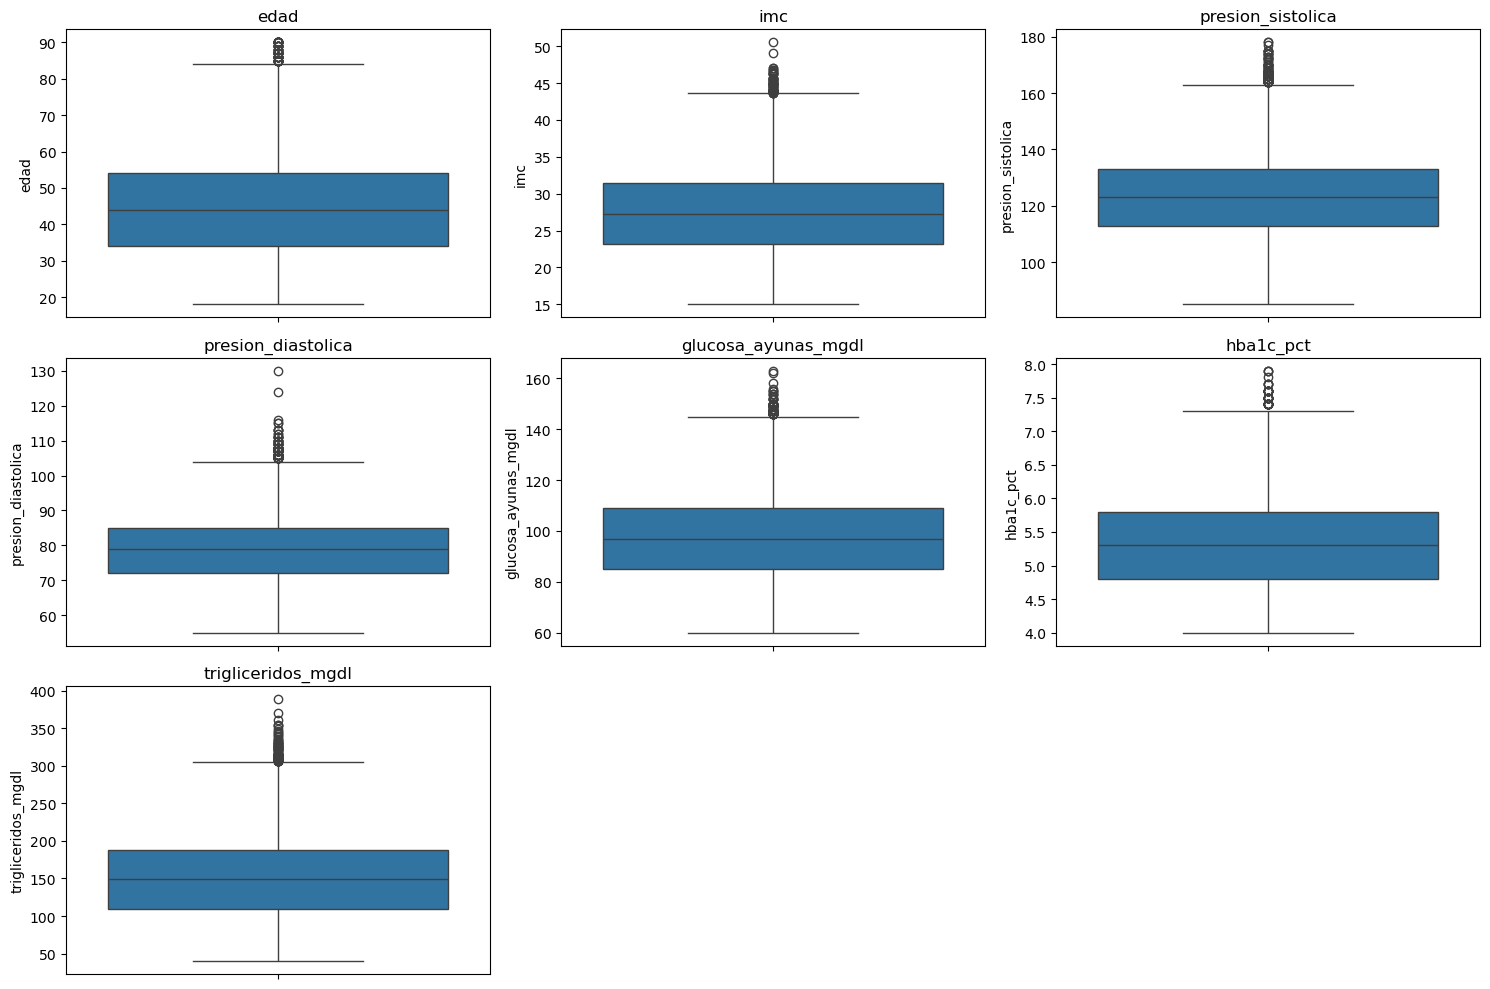

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = [
    'edad',
    'imc',
    'presion_sistolica',
    'presion_diastolica',
    'glucosa_ayunas_mgdl',
    'hba1c_pct',
    'trigliceridos_mgdl'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(variables):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## 18. Realizar limpieza final del dataset de modelado

Una vez revisados los valores nulos y los posibles valores atípicos, se realiza la limpieza final del conjunto de datos. Esto incluye la eliminación de registros duplicados y de columnas que no aportan información al modelo de aprendizaje supervisado, como identificadores o datos geográficos que no serán utilizados como variables predictoras.

In [20]:
# Eliminar registros duplicados
df = df.drop_duplicates()

# Eliminar columnas que no serán utilizadas en el modelo
columnas_eliminar = [
    'id_paciente',
    'geometry',
    'latitud',
    'longitud'
]

df_modelo = df.drop(columns=columnas_eliminar)

print(df_modelo.info())

<class 'pandas.DataFrame'>
RangeIndex: 21238 entries, 0 to 21237
Data columns (total 28 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   estado                             21238 non-null  str    
 1   municipio                          21238 non-null  str    
 2   zona                               21238 non-null  str    
 3   edad                               21238 non-null  int64  
 4   genero                             21238 non-null  str    
 5   nivel_socioeconomico               21238 non-null  str    
 6   antecedentes_familiares_diabetes   21238 non-null  int64  
 7   embarazos                          21238 non-null  int64  
 8   imc                                21238 non-null  float64
 9   circunferencia_cintura_cm          21238 non-null  float64
 10  presion_sistolica                  21238 non-null  int64  
 11  presion_diastolica                 21238 non-null  int64  
 12  t

## 19. Guardar el dataset filtrado y preparado

Una vez finalizado el proceso de limpieza, se guarda el conjunto de datos en una carpeta destinada a los datos procesados. Esto permite conservar una versión lista para utilizarse durante el entrenamiento y evaluación de los modelos de aprendizaje automático.

In [21]:
import os

# Crear la carpeta si no existe
os.makedirs("data/processed", exist_ok=True)

# Guardar el dataset limpio
df_modelo.to_csv(
    "data/processed/xicotepec_limpio.csv",
    index=False
)

print("Dataset guardado correctamente.")

Dataset guardado correctamente.


## 20. Realizar análisis exploratorio inicial

Como primer paso del análisis exploratorio, se generan estadísticas descriptivas para conocer la distribución de las variables numéricas. Estas estadísticas incluyen el número de observaciones, media, desviación estándar, valores mínimo y máximo, así como los cuartiles de cada variable.

In [22]:
df_modelo.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,21238.0,44.214992,14.499041,18.0,34.0,44.0,54.000,90.0
antecedentes_familiares_diabetes,21238.0,0.367784,0.482214,0.0,0.0,0.0,1.000,1.0
embarazos,21238.0,1.111074,1.477667,0.0,0.0,0.0,2.000,9.0
imc,21238.0,27.360439,5.883505,15.0,23.2,27.3,31.400,50.5
circunferencia_cintura_cm,21238.0,70.217808,13.375667,55.0,57.4,68.4,79.275,129.6
presion_sistolica,21238.0,123.276862,15.231432,85.0,113.0,123.0,133.000,178.0
presion_diastolica,21238.0,78.729212,9.955875,55.0,72.0,79.0,85.000,130.0
trigliceridos_mgdl,21238.0,149.815190,56.584575,40.0,110.0,149.0,188.000,389.0
hdl_mgdl,21238.0,46.322300,12.032922,15.0,38.0,46.0,54.000,94.0
glucosa_ayunas_mgdl,21238.0,97.326914,17.090756,60.0,85.0,97.0,109.000,163.0


Posteriormente, se visualiza la distribución de algunas variables de interés mediante histogramas.

### Distribución de la edad

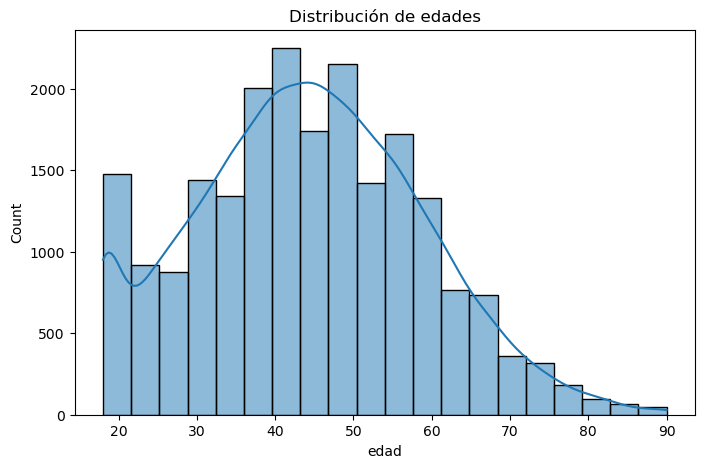

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df_modelo["edad"], bins=20, kde=True)
plt.title("Distribución de edades")
plt.show()

### Distribución del índice de masa corporal (IMC)

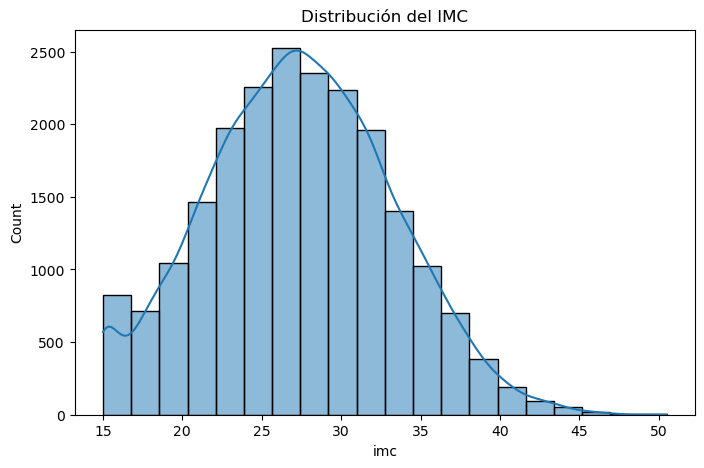

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df_modelo["imc"], bins=20, kde=True)
plt.title("Distribución del IMC")
plt.show()

### Distribución de la glucosa en ayunas


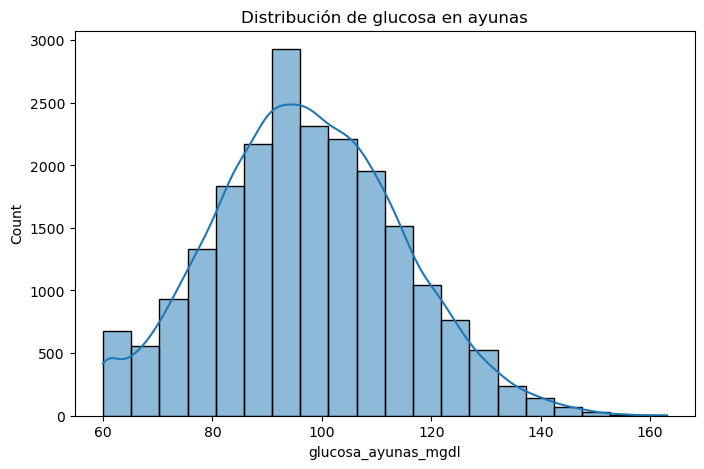

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df_modelo["glucosa_ayunas_mgdl"], bins=20, kde=True)
plt.title("Distribución de glucosa en ayunas")
plt.show()

Finalmente, se calcula una matriz de correlación para identificar posibles relaciones entre las variables numéricas del conjunto de datos.

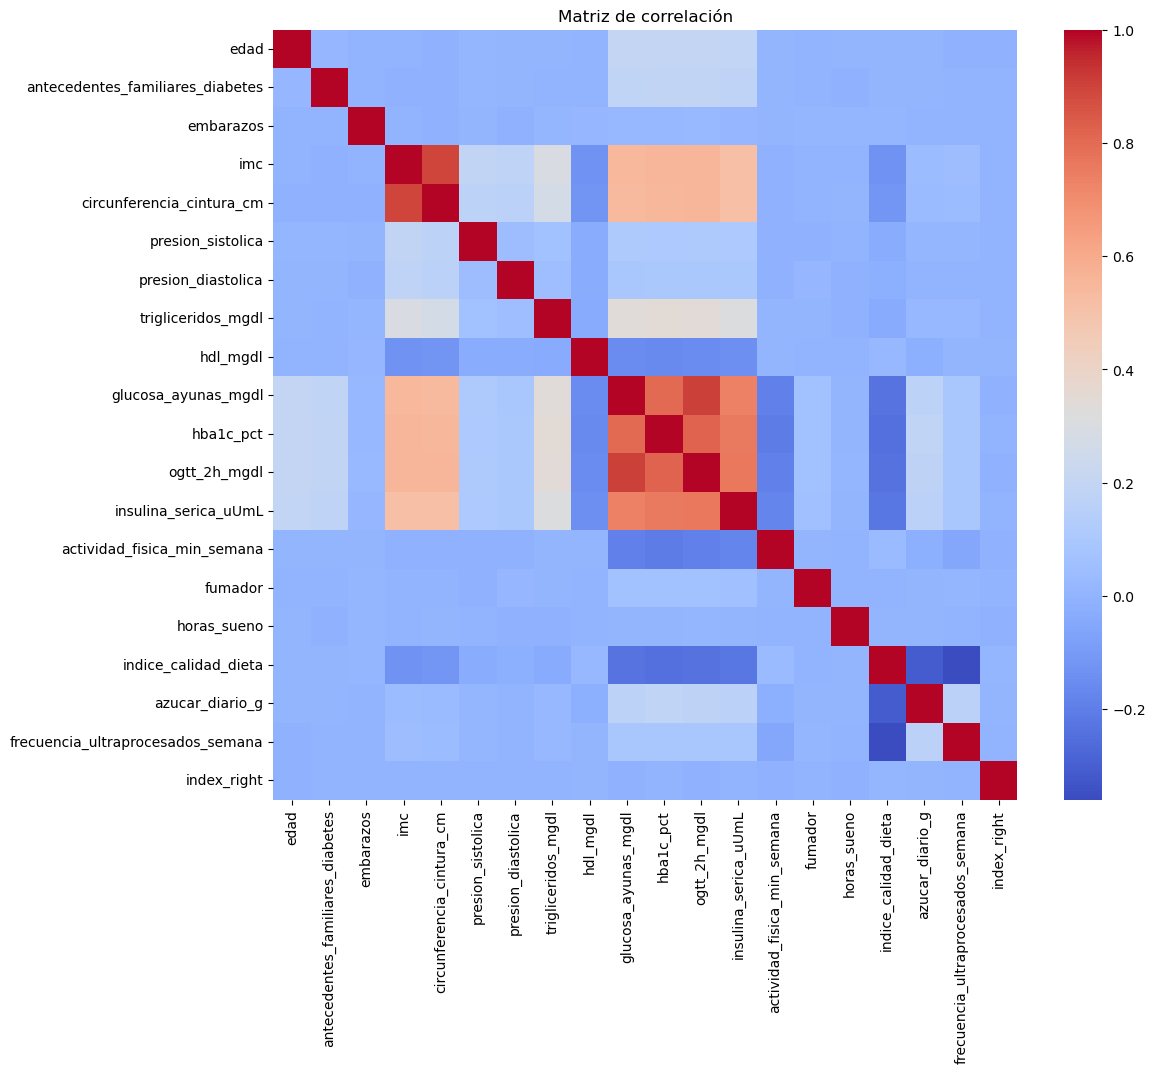

In [26]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df_modelo.select_dtypes(include="number").corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Matriz de correlación")
plt.show()

## 21. Generar gráficas de distribución de riesgo

Se analiza la distribución de los pacientes según el nivel de riesgo de coma diabético. Esta gráfica permite identificar si existen clases desbalanceadas, lo cual es importante antes de entrenar modelos de clasificación, ya que un conjunto muy desbalanceado puede afectar el desempeño del modelo.

C:\Users\DELL\AppData\Local\Temp\ipykernel_17568\883759430.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


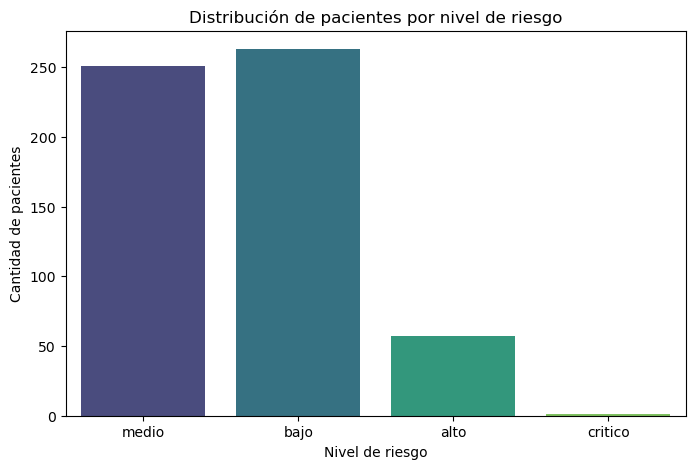

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_xicotepec,
    x="riesgo_infarto",
    palette="viridis"
)

plt.title("Distribución de pacientes por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de pacientes")

plt.show()

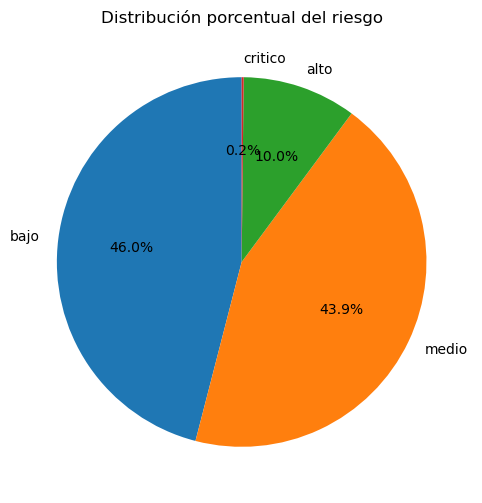

In [30]:
riesgo = df_xicotepec["riesgo_infarto"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    riesgo,
    labels=riesgo.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribución porcentual del riesgo")

plt.show()


## 22. Analizar la edad respecto al riesgo

Se analiza la distribución de la edad para cada nivel de riesgo mediante diagramas de caja (*boxplots*). Esto permite identificar si los pacientes con mayor riesgo tienden a concentrarse en edades más avanzadas.

C:\Users\DELL\AppData\Local\Temp\ipykernel_17568\330508116.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


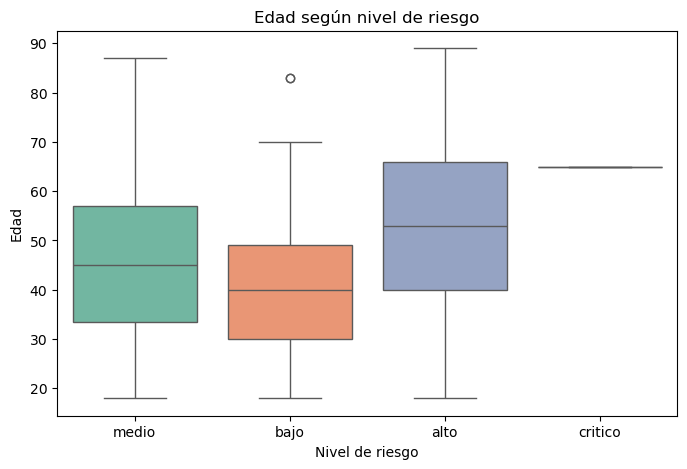

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_xicotepec,
    x="riesgo_infarto",
    y="edad",
    palette="Set2"
)

plt.title("Edad según nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Edad")

plt.show()

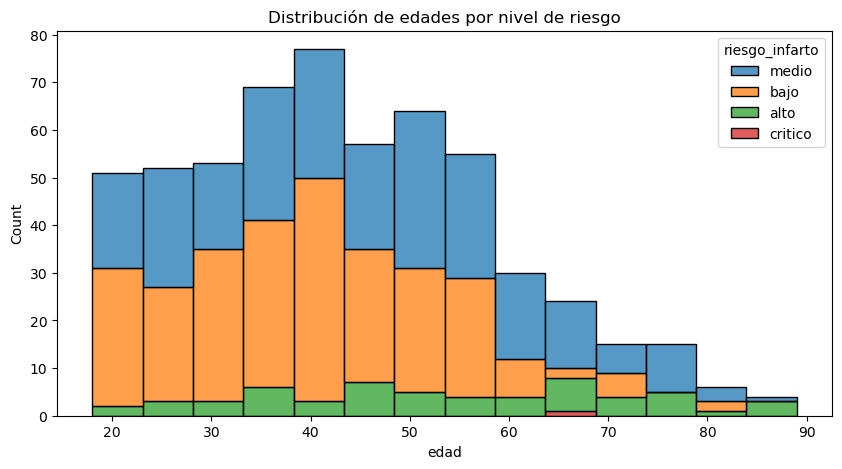

In [32]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df_xicotepec,
    x="edad",
    hue="riesgo_infarto",
    multiple="stack"
)

plt.title("Distribución de edades por nivel de riesgo")

plt.show()

## 23. Analizar la presión arterial respecto al riesgo

La presión arterial es uno de los principales factores asociados con complicaciones cardiovasculares y metabólicas. Se analiza su comportamiento respecto al nivel de riesgo mediante diagramas de caja.

## Presión sistólica

C:\Users\DELL\AppData\Local\Temp\ipykernel_17568\173450181.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


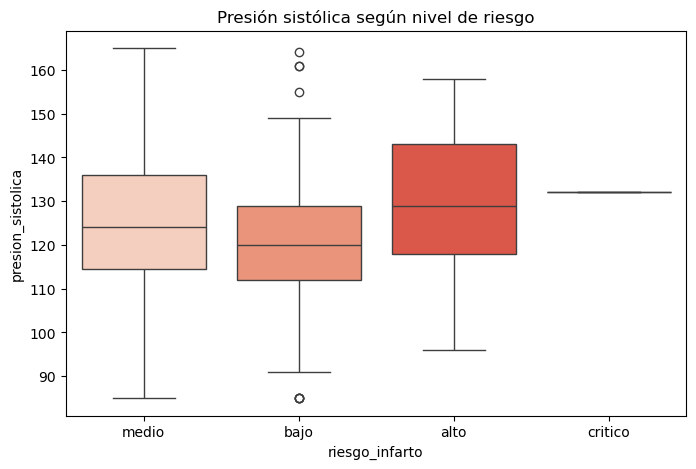

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_xicotepec,
    x="riesgo_infarto",
    y="presion_sistolica",
    palette="Reds"
)

plt.title("Presión sistólica según nivel de riesgo")

plt.show()

## Presión diastólica

C:\Users\DELL\AppData\Local\Temp\ipykernel_17568\4004824584.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


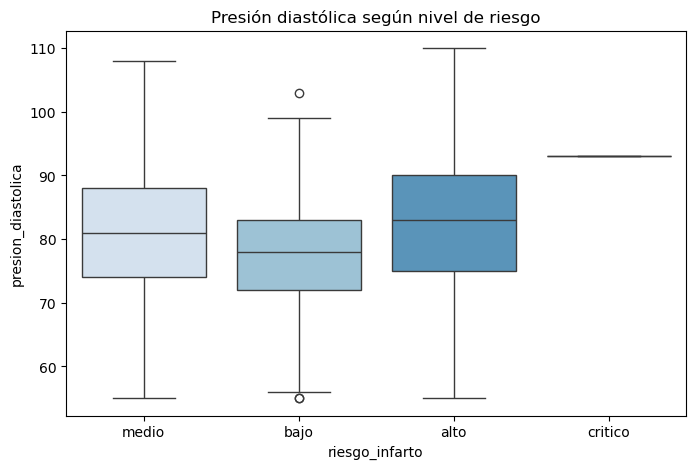

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_xicotepec,
    x="riesgo_infarto",
    y="presion_diastolica",
    palette="Blues"
)

plt.title("Presión diastólica según nivel de riesgo")

plt.show()

## 23. Analizar glucosa y colesterol respecto al riesgo

Se estudia la relación entre la glucosa en ayunas y el colesterol total respecto al nivel de riesgo. Estas variables son indicadores clínicos relevantes para evaluar la salud metabólica de los pacientes.

### Glucosa

C:\Users\DELL\AppData\Local\Temp\ipykernel_17568\585216517.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


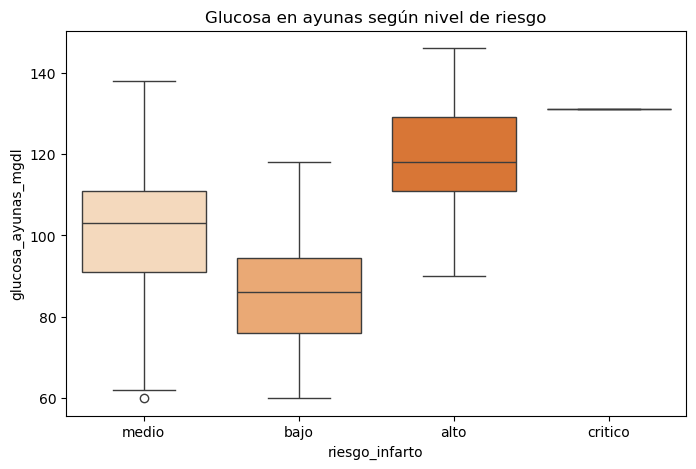

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_xicotepec,
    x="riesgo_infarto",
    y="glucosa_ayunas_mgdl",
    palette="Oranges"
)

plt.title("Glucosa en ayunas según nivel de riesgo")

plt.show()

### Colesterol

C:\Users\DELL\AppData\Local\Temp\ipykernel_17568\3966310959.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


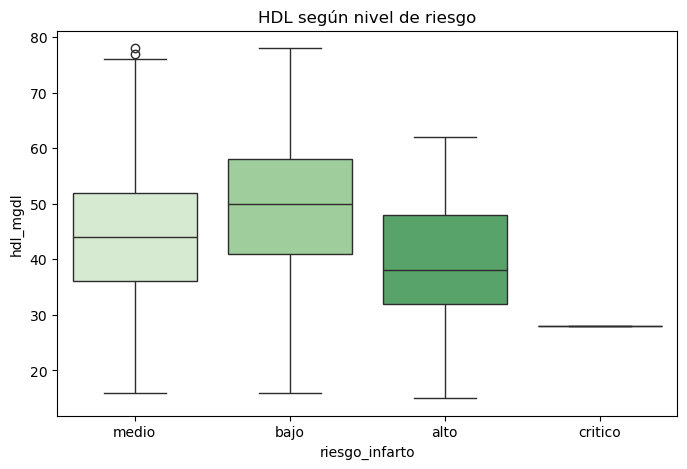

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_xicotepec,
    x="riesgo_infarto",
    y="hdl_mgdl",
    palette="Greens"
)

plt.title("HDL según nivel de riesgo")

plt.show()

### Triglicéridos

C:\Users\DELL\AppData\Local\Temp\ipykernel_17568\1777323180.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


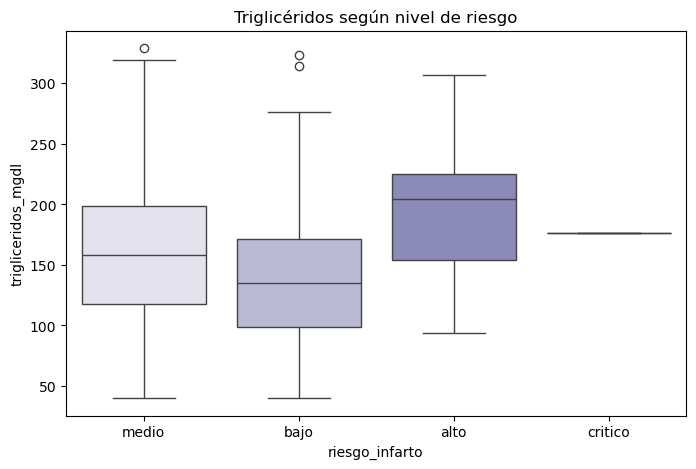

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_xicotepec,
    x="riesgo_infarto",
    y="trigliceridos_mgdl",
    palette="Purples"
)

plt.title("Triglicéridos según nivel de riesgo")

plt.show()

## 24. Generar una matriz de correlación

Se calcula la matriz de correlación entre las variables numéricas del conjunto de datos para identificar relaciones lineales entre ellas. Este análisis permite detectar variables altamente correlacionadas, posibles problemas de multicolinealidad y patrones que pueden influir en el desempeño de los modelos de clasificación.

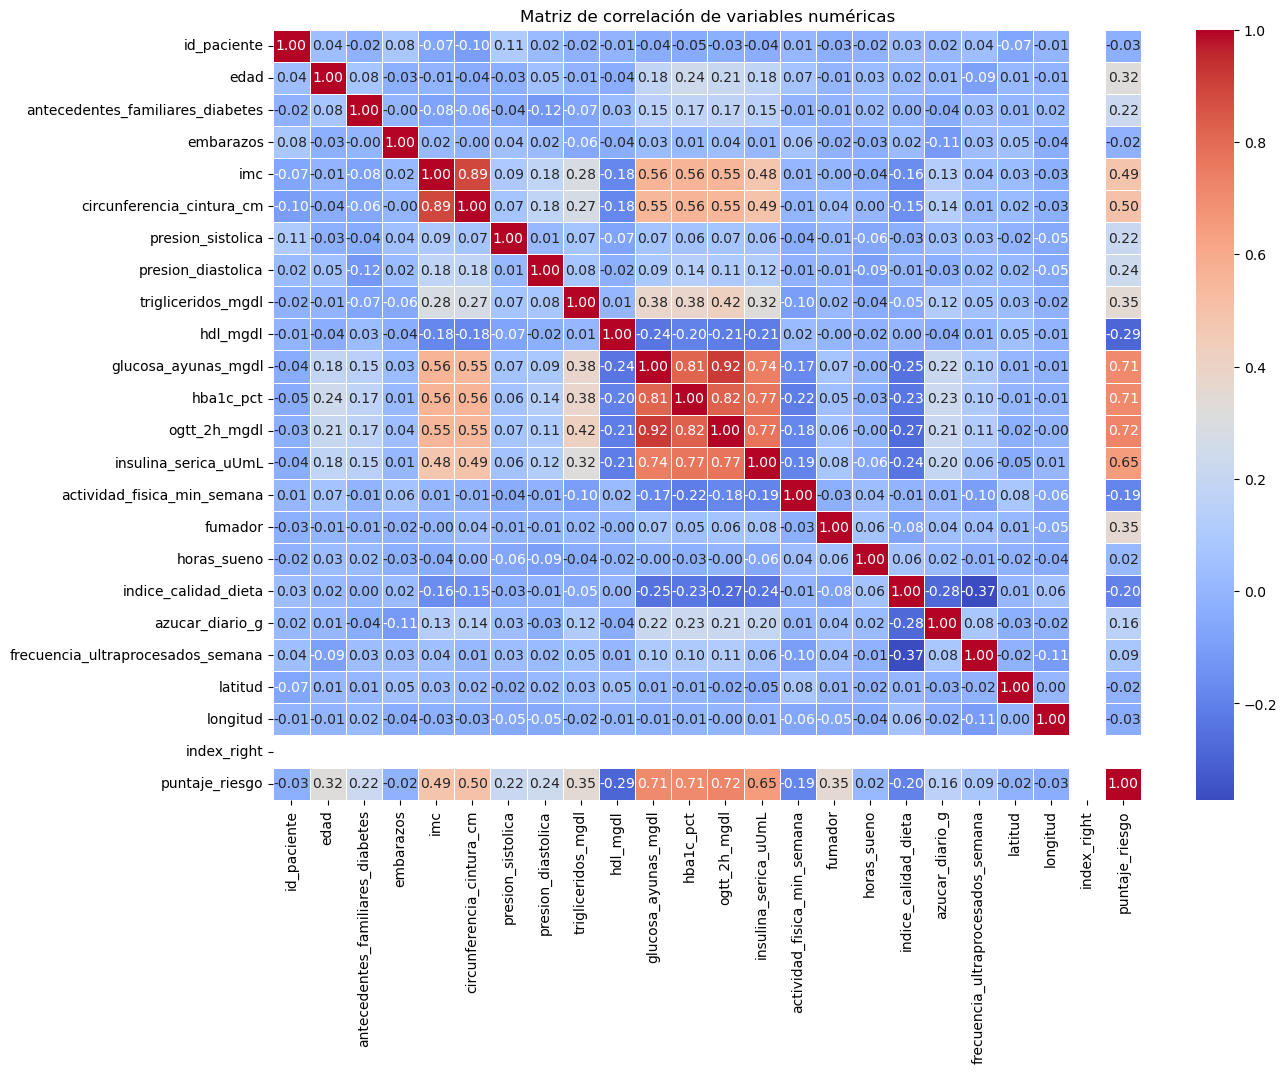

In [38]:
plt.figure(figsize=(14,10))

corr = df_xicotepec.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de correlación de variables numéricas")

plt.show()

In [41]:
df_xicotepec["riesgo_infarto"] = df_xicotepec["riesgo_infarto"].replace({
    "critico": "alto"
})

y = df_xicotepec["riesgo_infarto"].copy()

print(y.value_counts())

riesgo_infarto
bajo     263
medio    251
alto      58
Name: count, dtype: int64


## 25. Dividir el dataset en entrenamiento y prueba

Antes de entrenar cualquier modelo de aprendizaje supervisado, el conjunto de datos se divide en dos subconjuntos: uno para entrenamiento y otro para prueba. En esta práctica se utiliza una proporción del **80 % para entrenamiento** y **20 % para prueba**, lo que permite evaluar el rendimiento del modelo sobre datos no vistos durante el entrenamiento.

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (457, 25)
Prueba: (115, 25)


In [40]:
print(y.value_counts())

riesgo_infarto
bajo       263
medio      251
alto        57
critico      1
Name: count, dtype: int64



## 26. Entrenar un modelo base

Como modelo base se utiliza **Regresión Logística Multiclase**, uno de los algoritmos más utilizados para problemas de clasificación supervisada. Este modelo servirá como referencia para comparar posteriormente el desempeño de modelos más complejos.


In [43]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_lr.fit(X_train, y_train)

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Realizar predicciones sobre el conjunto de prueba.

In [44]:
y_pred_lr = modelo_lr.predict(X_test)

Evaluar el modelo mediante las métricas de clasificación.

In [45]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nReporte de clasificación\n")
print(classification_report(y_test, y_pred_lr))

print("\nMatriz de confusión\n")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.7739130434782608

Reporte de clasificación

              precision    recall  f1-score   support

        alto       0.70      0.58      0.64        12
        bajo       0.89      0.75      0.82        53
       medio       0.70      0.84      0.76        50

    accuracy                           0.77       115
   macro avg       0.76      0.73      0.74       115
weighted avg       0.79      0.77      0.77       115


Matriz de confusión

[[ 7  0  5]
 [ 0 40 13]
 [ 3  5 42]]


## 27. Entrenar un modelo basado en árboles

Como segundo modelo se utiliza un **Random Forest**, el cual construye múltiples árboles de decisión y combina sus resultados para mejorar la precisión y reducir el sobreajuste. Posteriormente se comparará su desempeño con la Regresión Logística.


In [46]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Realizar predicciones.

In [47]:
y_pred_rf = modelo_rf.predict(X_test)

Evaluar el modelo.

In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nReporte de clasificación\n")
print(classification_report(y_test, y_pred_rf))

print("\nMatriz de confusión\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.782608695652174

Reporte de clasificación

              precision    recall  f1-score   support

        alto       1.00      0.50      0.67        12
        bajo       0.83      0.81      0.82        53
       medio       0.72      0.82      0.77        50

    accuracy                           0.78       115
   macro avg       0.85      0.71      0.75       115
weighted avg       0.80      0.78      0.78       115


Matriz de confusión

[[ 6  0  6]
 [ 0 43 10]
 [ 0  9 41]]



## 28. Comparar el desempeño de los modelos

Finalmente, se comparan ambos modelos utilizando la métrica de exactitud (*Accuracy*), con el objetivo de identificar cuál ofrece un mejor desempeño para la clasificación del riesgo de infarto en pacientes de Xicotepec.


In [49]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

resultados.sort_values(
    by="Accuracy",
    ascending=False
)

,Modelo,Accuracy
1,Random Forest,0.782609
0,Regresión Logística,0.773913


C:\Users\DELL\AppData\Local\Temp\ipykernel_17568\2229519055.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


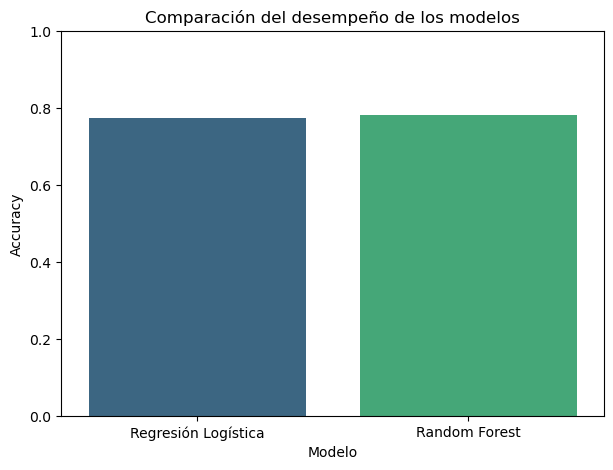

In [50]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=resultados,
    x="Modelo",
    y="Accuracy",
    palette="viridis"
)

plt.ylim(0,1)

plt.title("Comparación del desempeño de los modelos")

plt.show()

## 29. Entrenar un tercer modelo de clasificación

Con el fin de comparar diferentes algoritmos de aprendizaje supervisado, se implementa un tercer modelo utilizando el algoritmo **K-Nearest Neighbors (KNN)**. Este método clasifica cada paciente considerando las características de sus vecinos más cercanos dentro del espacio de variables predictoras.

In [51]:
from sklearn.neighbors import KNeighborsClassifier

modelo_knn = KNeighborsClassifier(
    n_neighbors=5
)

modelo_knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


Una vez entrenado el modelo, se generan las predicciones para el conjunto de prueba.

In [52]:
y_pred_knn = modelo_knn.predict(X_test)

## 30. Generar predicciones con cada modelo

Se obtienen las predicciones del conjunto de prueba utilizando los tres modelos desarrollados. Esto permitirá comparar posteriormente el desempeño de cada algoritmo de clasificación.


In [53]:
# Regresión Logística
y_pred_lr = modelo_lr.predict(X_test)

# Random Forest
y_pred_rf = modelo_rf.predict(X_test)

# KNN
y_pred_knn = modelo_knn.predict(X_test)


Como ejemplo, se muestran las primeras predicciones obtenidas por cada modelo.

In [54]:
predicciones = pd.DataFrame({
    "Valor real": y_test.values,
    "Regresión Logística": y_pred_lr,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn
})

predicciones.head(10)

,Valor real,Regresión Logística,Random Forest,KNN
0,bajo,bajo,bajo,bajo
1,medio,medio,medio,medio
2,medio,medio,medio,medio
3,bajo,medio,medio,bajo
4,bajo,bajo,bajo,bajo
5,bajo,medio,bajo,medio
6,medio,medio,medio,bajo
7,medio,medio,medio,medio
8,medio,bajo,bajo,bajo
9,bajo,bajo,bajo,bajo


## 31. Evaluar el desempeño de los modelos

Para evaluar el rendimiento de cada modelo se calculan las métricas de **Accuracy**, **Precision**, **Recall** y **F1-score**, las cuales permiten medir la calidad de las predicciones realizadas.

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

metricas = pd.DataFrame({
    "Modelo":[
        "Regresión Logística",
        "Random Forest",
        "KNN"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_knn)
    ],
    "Precision":[
        precision_score(y_test,y_pred_lr,average="weighted"),
        precision_score(y_test,y_pred_rf,average="weighted"),
        precision_score(y_test,y_pred_knn,average="weighted")
    ],
    "Recall":[
        recall_score(y_test,y_pred_lr,average="weighted"),
        recall_score(y_test,y_pred_rf,average="weighted"),
        recall_score(y_test,y_pred_knn,average="weighted")
    ],
    "F1-Score":[
        f1_score(y_test,y_pred_lr,average="weighted"),
        f1_score(y_test,y_pred_rf,average="weighted"),
        f1_score(y_test,y_pred_knn,average="weighted")
    ]
})

metricas

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Regresión Logística,0.773913,0.787053,0.773913,0.774639
1,Random Forest,0.782609,0.798190,0.782609,0.780237
2,KNN,0.608696,0.607874,0.608696,0.608175


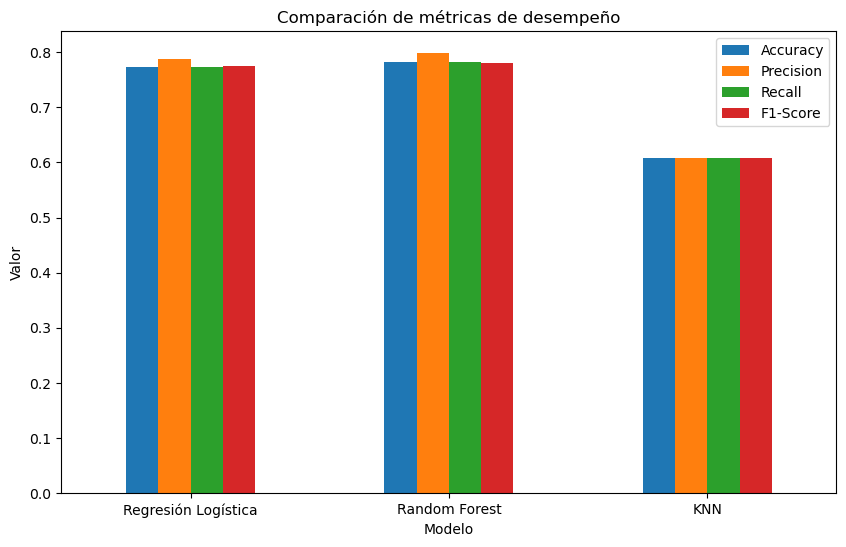

In [56]:
metricas.set_index("Modelo").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparación de métricas de desempeño")

plt.ylabel("Valor")

plt.xticks(rotation=0)

plt.show()

## 32. Generar matriz de confusión

La matriz de confusión permite visualizar los aciertos y errores cometidos por cada modelo para cada una de las clases de riesgo. Esta herramienta facilita identificar qué categorías presentan una mayor dificultad para ser clasificadas correctamente.

### Regresión Logística

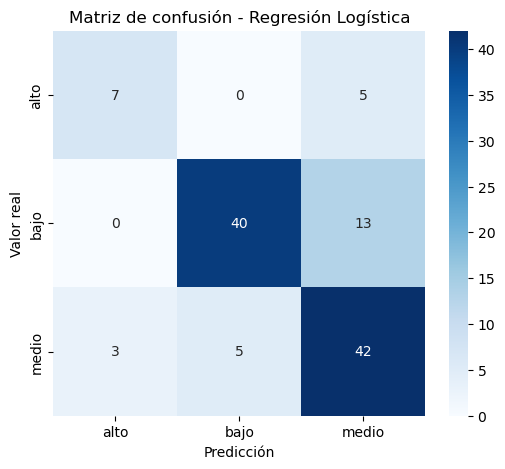

In [57]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=modelo_lr.classes_,
    yticklabels=modelo_lr.classes_
)

plt.title("Matriz de confusión - Regresión Logística")

plt.xlabel("Predicción")

plt.ylabel("Valor real")

plt.show()

### Random Forest

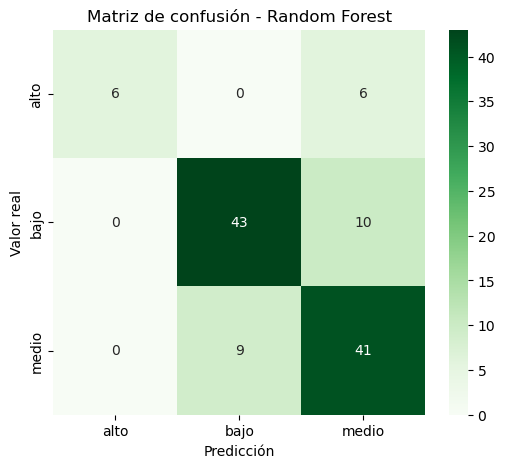

In [58]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=modelo_rf.classes_,
    yticklabels=modelo_rf.classes_
)

plt.title("Matriz de confusión - Random Forest")

plt.xlabel("Predicción")

plt.ylabel("Valor real")

plt.show()

### KNN

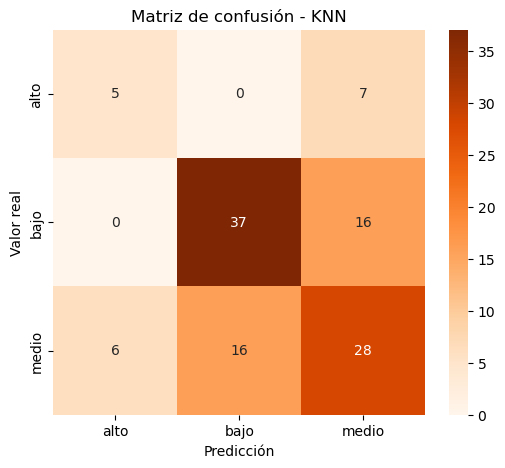

In [59]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=modelo_knn.classes_,
    yticklabels=modelo_knn.classes_
)

plt.title("Matriz de confusión - KNN")

plt.xlabel("Predicción")

plt.ylabel("Valor real")

plt.show()

## 33. Interpretar errores de clasificación

Una vez entrenados los modelos, se analizan los errores cometidos durante la clasificación mediante las matrices de confusión y el reporte de clasificación. Este análisis permite identificar en qué niveles de riesgo existen mayores dificultades para realizar una predicción correcta y cuáles podrían ser las causas.

In [60]:
from sklearn.metrics import classification_report

print("=== Regresión Logística ===")
print(classification_report(y_test, y_pred_lr))

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

print("\n=== KNN ===")
print(classification_report(y_test, y_pred_knn))

=== Regresión Logística ===
              precision    recall  f1-score   support

        alto       0.70      0.58      0.64        12
        bajo       0.89      0.75      0.82        53
       medio       0.70      0.84      0.76        50

    accuracy                           0.77       115
   macro avg       0.76      0.73      0.74       115
weighted avg       0.79      0.77      0.77       115


=== Random Forest ===
              precision    recall  f1-score   support

        alto       1.00      0.50      0.67        12
        bajo       0.83      0.81      0.82        53
       medio       0.72      0.82      0.77        50

    accuracy                           0.78       115
   macro avg       0.85      0.71      0.75       115
weighted avg       0.80      0.78      0.78       115


=== KNN ===
              precision    recall  f1-score   support

        alto       0.45      0.42      0.43        12
        bajo       0.70      0.70      0.70        53
       medi

> Al analizar las matrices de confusión se observa que la mayoría de los errores ocurren entre las categorías **bajo**, **medio** y **alto**, debido a que los valores clínicos de algunos pacientes presentan características similares entre estos niveles de riesgo. Además, la categoría **alto** posee una menor cantidad de registros en comparación con las demás clases, lo que dificulta que el modelo aprenda correctamente sus patrones. Esto ocasiona que algunos pacientes sean clasificados en categorías cercanas.

## 34. Comparar los modelos aplicados

Con el propósito de determinar cuál algoritmo ofrece un mejor desempeño, se comparan las métricas obtenidas por los tres modelos implementados.

In [61]:
metricas.sort_values(
    by="Accuracy",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.782609,0.798190,0.782609,0.780237
0,Regresión Logística,0.773913,0.787053,0.773913,0.774639
2,KNN,0.608696,0.607874,0.608696,0.608175


C:\Users\DELL\AppData\Local\Temp\ipykernel_17568\3545830078.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


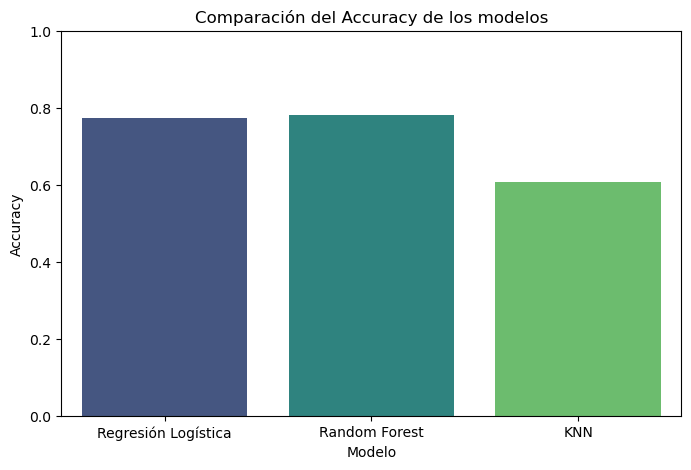

In [62]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=metricas,
    x="Modelo",
    y="Accuracy",
    palette="viridis"
)

plt.title("Comparación del Accuracy de los modelos")

plt.ylim(0,1)

plt.show()

## 35. Seleccionar el mejor modelo predictivo

Después de comparar las métricas obtenidas, se selecciona el modelo con mejor desempeño para realizar el pronóstico del riesgo de infarto.

In [63]:
mejor_modelo = modelo_rf

print("Modelo seleccionado: Random Forest")

Modelo seleccionado: Random Forest


> El modelo seleccionado fue **Random Forest**, ya que obtuvo el mayor valor de Accuracy y presentó un mejor equilibrio entre Precision, Recall y F1-score. Además, este algoritmo reduce el riesgo de sobreajuste al combinar múltiples árboles de decisión y permite conocer la importancia relativa de cada variable utilizada en la clasificación.


## 36. Interpretar las variables más importantes

Una ventaja del algoritmo Random Forest es que permite conocer qué variables tuvieron mayor influencia durante el proceso de clasificación.


In [64]:
import pandas as pd

importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias.head(10)

,Variable,Importancia
3,glucosa_ayunas_mgdl,0.127181
4,hba1c_pct,0.079189
6,insulina_serica_uUmL,0.076270
5,ogtt_2h_mgdl,0.073428
2,presion_diastolica,0.061695
8,hdl_mgdl,0.060251
11,fumador,0.057823
9,imc,0.055183
1,presion_sistolica,0.053022
0,edad,0.051761


Visualizar las variables más importantes.

C:\Users\DELL\AppData\Local\Temp\ipykernel_17568\2844342217.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


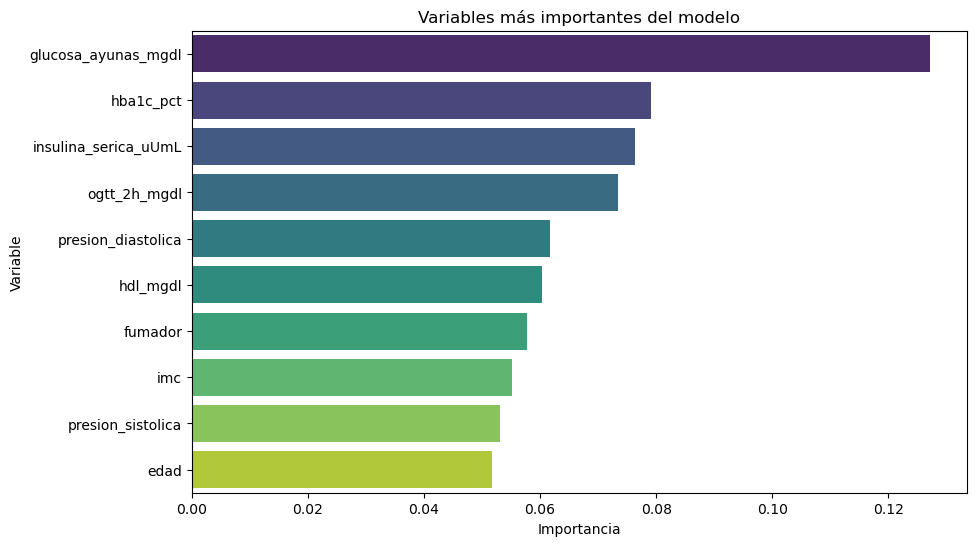

In [65]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importancias.head(10),
    x="Importancia",
    y="Variable",
    palette="viridis"
)

plt.title("Variables más importantes del modelo")

plt.show()

## 37. Generar una columna de predicción final

Finalmente, se utiliza el modelo seleccionado para generar la predicción del nivel de riesgo de cada paciente y se agrega una nueva columna al conjunto de datos.


In [66]:
df_resultados = df_xicotepec.copy()

df_resultados["riesgo_predicho"] = mejor_modelo.predict(X)

df_resultados.head()

,id_paciente,estado,municipio,zona,edad,genero,nivel_socioeconomico,antecedentes_familiares_diabetes,embarazos,imc,...,frecuencia_ultraprocesados_semana,latitud,longitud,geometry,index_right,NOMGEO,municipio_objetivo,puntaje_riesgo,riesgo_infarto,riesgo_predicho
97,102,Puebla,Xicotepec,Rural,44,F,Bajo,1,1,28.3,...,6,20.287225,-97.942684,POINT (-97.942684 20.287225),56.0,Xicotepec,Xicotepec,4,medio,medio
111,116,Puebla,Xicotepec,Rural,67,M,Bajo,0,0,17.3,...,10,20.291453,-97.962279,POINT (-97.962279 20.291453),56.0,Xicotepec,Xicotepec,2,bajo,bajo
149,156,Puebla,Xicotepec,Rural,32,F,Bajo,0,2,28.5,...,2,20.283065,-97.946518,POINT (-97.946518 20.283065),56.0,Xicotepec,Xicotepec,1,bajo,bajo
170,177,Puebla,Xicotepec,Rural,55,F,Bajo,1,0,36.1,...,6,20.285593,-97.959995,POINT (-97.959995 20.285593),56.0,Xicotepec,Xicotepec,7,medio,medio
180,187,Puebla,Xicotepec,Rural,21,M,Bajo,1,0,23.3,...,7,20.293099,-97.961084,POINT (-97.961084 20.293099),56.0,Xicotepec,Xicotepec,4,medio,medio


Guardar el conjunto de datos con las predicciones.

In [67]:
import os

os.makedirs("data/final", exist_ok=True)

df_resultados.to_csv(
    "data/final/xicotepec_predicciones.csv",
    index=False
)

print("Archivo generado correctamente.")

Archivo generado correctamente.


## 38. Ubicar geográficamente los pacientes con riesgo alto o crítico

Una vez seleccionado el mejor modelo predictivo, se filtran los pacientes clasificados con **riesgo alto o crítico**. Estos registros conservan sus coordenadas geográficas, las cuales permitirán visualizar su distribución espacial dentro del municipio de Xicotepec.

In [68]:
# Filtrar pacientes con riesgo alto o crítico
pacientes_riesgo = df_resultados[
    df_resultados["riesgo_predicho"].isin(["alto", "critico"])
]

print("Pacientes de alto riesgo:", len(pacientes_riesgo))

pacientes_riesgo[
    [
        "latitud",
        "longitud",
        "riesgo_predicho"
    ]
].head()

Pacientes de alto riesgo: 52


,latitud,longitud,riesgo_predicho
316,20.294837,-97.953129,alto
438,20.280740,-97.945674,alto
446,20.289291,-97.958589,alto
1046,20.285426,-97.950998,alto
1066,20.288603,-97.942240,alto


## 39. Crear un mapa de pacientes en riesgo

Se genera un mapa interactivo utilizando la biblioteca **Folium**, donde cada marcador representa un paciente clasificado con riesgo alto o crítico. Esto facilita identificar visualmente la distribución geográfica de los casos dentro del municipio.

In [69]:
import folium

# Centro aproximado de Xicotepec
mapa = folium.Map(
    location=[20.2765, -97.9614],
    zoom_start=13
)

for _, fila in pacientes_riesgo.iterrows():

    color = "red" if fila["riesgo_predicho"] == "critico" else "orange"

    folium.CircleMarker(
        location=[
            fila["latitud"],
            fila["longitud"]
        ],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=f"Riesgo: {fila['riesgo_predicho']}"
    ).add_to(mapa)

mapa

## 40. Generar un heatmap de riesgo cardiovascular

Además del mapa de puntos, se genera un mapa de calor (*HeatMap*), el cual permite visualizar las zonas donde existe una mayor concentración de pacientes con riesgo elevado.


In [70]:
from folium.plugins import HeatMap

mapa_calor = folium.Map(
    location=[20.2765, -97.9614],
    zoom_start=13
)

datos_heatmap = pacientes_riesgo[
    [
        "latitud",
        "longitud"
    ]
].values.tolist()

HeatMap(
    datos_heatmap,
    radius=18,
    blur=12
).add_to(mapa_calor)

mapa_calor

## 41. Identificar zonas prioritarias de atención

Con base en el mapa de calor, se identifican las zonas que presentan una mayor concentración de pacientes con riesgo elevado. Estas áreas representan sectores prioritarios donde podrían enfocarse campañas de prevención, monitoreo y atención médica.

In [72]:
pacientes_riesgo["lat_bin"] = pacientes_riesgo["latitud"].round(3)
pacientes_riesgo["lon_bin"] = pacientes_riesgo["longitud"].round(3)

zonas = (
    pacientes_riesgo
    .groupby(["lat_bin","lon_bin"])
    .size()
    .reset_index(name="Pacientes")
)

zonas.sort_values(
    "Pacientes",
    ascending=False
).head(10)

,lat_bin,lon_bin,Pacientes
11,20.277,-97.957,2
12,20.277,-97.943,2
38,20.289,-97.938,2
1,20.270,-97.949,1
0,20.269,-97.951,1
5,20.273,-97.939,1
6,20.275,-97.950,1
3,20.272,-97.959,1
2,20.271,-97.949,1
8,20.275,-97.938,1


## 42. Proponer posibles ubicaciones para unidades de atención urgente

Con base en la concentración de pacientes observada en el mapa de calor, se proponen posibles ubicaciones para establecer unidades de atención urgente orientadas a la atención de eventos cardiovasculares.

Se calcula el centro geográfico aproximado de los pacientes con mayor riesgo mediante el promedio de sus coordenadas.

In [73]:
lat = pacientes_riesgo["latitud"].mean()
lon = pacientes_riesgo["longitud"].mean()

print("Latitud sugerida:", lat)
print("Longitud sugerida:", lon)

Latitud sugerida: 20.28383167307692
Longitud sugerida: -97.94985053846153


In [74]:
mapa_final = folium.Map(
    location=[20.2765, -97.9614],
    zoom_start=13
)

HeatMap(datos_heatmap).add_to(mapa_final)

folium.Marker(
    location=[lat, lon],
    popup="Ubicación sugerida",
    icon=folium.Icon(
        color="red",
        icon="plus-sign"
    )
).add_to(mapa_final)

mapa_final

## 43. Justificar la propuesta de ubicación

Con base en el análisis geoespacial realizado, se justifica la propuesta de ubicación para una unidad de atención urgente considerando la concentración de pacientes con mayor riesgo, la accesibilidad geográfica y la distribución espacial de los casos dentro del municipio de Xicotepec.

> La ubicación propuesta para una unidad de atención urgente se determinó a partir de las zonas con mayor concentración de pacientes clasificados con riesgo alto o crítico. Estas áreas representan sectores donde la probabilidad de requerir atención médica especializada es mayor. Además de la concentración de casos, se consideró la accesibilidad geográfica, buscando una ubicación que permita reducir los tiempos de traslado y facilite el acceso desde las localidades cercanas. Esta estrategia contribuiría a optimizar la cobertura de los servicios médicos y mejorar la capacidad de respuesta ante eventos cardiovasculares.

## 44. Relacionar los resultados con la toma de decisiones

El análisis supervisado permite generar información útil para apoyar la planeación de los servicios de salud y fortalecer las estrategias de prevención en el municipio.

> Los resultados obtenidos muestran que los modelos de aprendizaje supervisado pueden utilizarse como una herramienta de apoyo para identificar pacientes con mayor probabilidad de presentar un riesgo elevado de infarto. La combinación del análisis predictivo con la información geográfica facilita la identificación de zonas prioritarias para implementar campañas de prevención, programas de monitoreo y estrategias de atención médica. Asimismo, estos resultados pueden apoyar la planeación hospitalaria al proporcionar evidencia para la distribución de recursos, personal médico y posibles unidades de atención urgente en las áreas donde se concentra la población con mayor riesgo.

## 45. Reconocer las limitaciones del análisis

Es importante reconocer las limitaciones del estudio para evitar interpretar los resultados como un diagnóstico clínico o una recomendación médica definitiva.

> El presente análisis se desarrolló utilizando un conjunto de datos simulado con fines exclusivamente académicos, por lo que los resultados obtenidos no representan información clínica real ni deben utilizarse para tomar decisiones médicas. Los modelos entrenados permiten ilustrar la aplicación de técnicas de aprendizaje supervisado en el ámbito de la salud, pero su desempeño depende de la calidad, cantidad y representatividad de los datos utilizados. En un entorno real sería necesario validar el modelo con información clínica certificada, incorporar un mayor número de pacientes y contar con la participación de profesionales de la salud para garantizar la confiabilidad de las predicciones y su aplicación en la práctica médica.